# 03 : Modélisation — CNN from scratch vs transfer learning

## Courte revue de l'état de l'art

Deux familles d'approches dominent aujourd'hui la classification d'images en deep learning. Entraîner un **réseau de neurones convolutif from scratch** permet à l'architecture et aux filtres de s'adapter exactement au domaine cible, au prix d'avoir besoin d'assez de données annotées et de calcul pour apprendre des filtres bas niveau utiles à partir de rien. Le **transfer learning** part d'un réseau pré-entraîné sur un grand dataset d'images génériques, typiquement ImageNet. Il réutilise ses filtres précoces (contours, textures, dégradés de couleur) et ne réentraîne que la ou les couches de classification finale. C'est l'approche standard quand les données annotées ou le calcul sont limités.

Une réserve toutefois : ces filtres ont été appris sur des photographies naturelles, pas sur de la microscopie colorée. Le bénéfice sur un domaine aussi éloigné d'ImageNet n'est pas garanti, il mérite d'être mesuré plutôt que supposé.

Ce notebook entraîne un modèle de chaque famille sur les mêmes données et les compare directement, plutôt que d'en choisir un a priori.

## 1. Configuration

In [1]:
import ssl
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from IPython.display import Markdown, display
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from src.malaria_pipeline import (
    MalariaCellDataset, SimpleCNN, build_resnet18_transfer, evaluate_model, train_model
)

# Le magasin de certificats Windows de cette machine contient une entrée qui fait
# lever ASN1_NOT_ENOUGH_DATA a ssl.create_default_context(), ce qui casserait
# sinon le telechargement des poids pre-entraines de resnet18 plus bas. On redirige
# le chargement par defaut des certificats vers le bundle CA de certifi (fix local au process).
try:
    import certifi

    _certifi_bundle = certifi.where()
    _original_load_default_certs = ssl.SSLContext.load_default_certs

    def _patched_load_default_certs(self, purpose=ssl.Purpose.SERVER_AUTH):
        try:
            self.load_verify_locations(cafile=_certifi_bundle)
        except Exception:
            _original_load_default_certs(self, purpose)

    ssl.SSLContext.load_default_certs = _patched_load_default_certs
except Exception:
    pass

sns.set_theme(style="whitegrid")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cpu")  # pas de CUDA sur cette machine
PROJECT_ROOT = Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

IMG_SIZE = 64
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
LABEL_TO_IDX = {"Uninfected": 0, "Parasitized": 1}
IDX_TO_LABEL = {v: k for k, v in LABEL_TO_IDX.items()}

print(f"Device : {DEVICE}")

Device : cpu


> **Contexte d'exécution.** Le calcul s'effectue sur CPU. Cette contrainte motive la résolution 64×64 et un protocole limité à huit époques, identique pour les deux modèles.


## 2. Chargement des manifestes complets

**Note de budget CPU :** cette machine n'a pas de GPU CUDA. Les benchmarks de la section 3 montrent qu'une epoch sur les ~19 300 images d'entraînement prend largement moins d'une minute par modèle, à une résolution de 64x64.

Toutes les images du split d'entraînement sont utilisées et la distribution issue du split groupé par patient est conservée.

In [2]:
train_full = pd.read_csv(PROCESSED_DIR / "train.csv")
val_df = pd.read_csv(PROCESSED_DIR / "val.csv")

train_df = train_full.reset_index(drop=True)

print(f"Jeu d'entraînement complet : {len(train_full):,} images")
print(f"Jeu d'entraînement complet utilisé : {len(train_df):,} images")
display(train_df["label"].value_counts())
print(f"Jeu de validation complet : {len(val_df):,} images")
display(val_df["label"].value_counts())

Jeu d'entraînement complet : 19,915 images
Jeu d'entraînement complet utilisé : 19,915 images


label
Parasitized    10234
Uninfected      9681
Name: count, dtype: int64

Jeu de validation complet : 3,623 images


label
Uninfected     2050
Parasitized    1573
Name: count, dtype: int64

> **Contrôle des données.** Les 19 915 images d'entraînement et 3 623 images de validation sont toutes utilisées. Le déséquilibre modéré de la validation justifie de suivre le F1 de la classe parasitée en complément de l'accuracy.


## 3. Datasets, transformations et dataloaders

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


train_dataset = MalariaCellDataset(train_df, PROJECT_ROOT, transform=train_transform)
val_dataset = MalariaCellDataset(val_df, PROJECT_ROOT, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)

print(f"{len(train_loader)} batchs d'entraînement, {len(val_loader)} batchs de validation par epoch")

623 batchs d'entraînement, 57 batchs de validation par epoch


> **Résultat de préparation.** Chaque époque parcourt 623 batchs d'entraînement et 57 batchs de validation. Les deux modèles recevront exactement les mêmes données et transformations.


## 4. Modèle 1 : petit CNN from scratch

In [4]:
simple_cnn = SimpleCNN().to(DEVICE)
n_params = sum(p.numel() for p in simple_cnn.parameters())
n_trainable = sum(p.numel() for p in simple_cnn.parameters() if p.requires_grad)
print(f"SimpleCNN : {n_params:,} paramètres au total, {n_trainable:,} entraînables")

SimpleCNN : 548,258 paramètres au total, 548,258 entraînables


> **Observation.** Le SimpleCNN compte 548 258 paramètres, tous entraînables. Il constitue une baseline spécialisée légère, mais doit apprendre ses représentations visuelles uniquement à partir des images de malaria.


## 5. Modèle 2 : transfer learning avec resnet18

In [5]:
resnet_transfer = build_resnet18_transfer().to(DEVICE)
n_params = sum(p.numel() for p in resnet_transfer.parameters())
n_trainable = sum(p.numel() for p in resnet_transfer.parameters() if p.requires_grad)
print(f"resnet18 transfer : {n_params:,} paramètres au total, {n_trainable:,} entraînables (couche fc uniquement)")

resnet18 transfer : 11,177,538 paramètres au total, 1,026 entraînables (couche fc uniquement)


> **Observation.** La ResNet18 contient 11,18 millions de paramètres, mais seuls les 1 026 paramètres de la couche finale sont entraînés. Cette configuration réduit le coût d'optimisation, tout en testant si les représentations ImageNet se transfèrent à la microscopie.


## 6. Entraînement des deux modèles

La fonction commune calcule la loss, l'accuracy et le F1 `Parasitized` à chaque époque, conserve le meilleur état selon l'accuracy de validation et mesure le temps total. Les deux entraînements utilisent ainsi le même protocole ; seules les architectures diffèrent.


In [6]:
# L'entraînement et l'évaluation réutilisables sont importés depuis src/malaria_pipeline.py.
EPOCHS = 8
LR = 1e-3

### 6.1 Entraînement du SimpleCNN

On entraîne d'abord la baseline from scratch. Les métriques affichées à chaque époque permettent de suivre la convergence et l'écart entre entraînement et validation.


In [7]:
history_cnn, time_cnn = train_model(simple_cnn, train_loader, val_loader, EPOCHS, LR, "SimpleCNN", DEVICE)

[SimpleCNN] epoch 1/8 - train_loss 0.2622 train_acc 0.8881 | val_loss 0.1227 val_acc 0.9658 val_f1 0.9604


[SimpleCNN] epoch 2/8 - train_loss 0.1488 train_acc 0.9527 | val_loss 0.1087 val_acc 0.9674 val_f1 0.9621


[SimpleCNN] epoch 3/8 - train_loss 0.1413 train_acc 0.9545 | val_loss 0.0940 val_acc 0.9688 val_f1 0.9639


[SimpleCNN] epoch 4/8 - train_loss 0.1360 train_acc 0.9548 | val_loss 0.1019 val_acc 0.9661 val_f1 0.9606


[SimpleCNN] epoch 5/8 - train_loss 0.1341 train_acc 0.9556 | val_loss 0.1016 val_acc 0.9688 val_f1 0.9641


[SimpleCNN] epoch 6/8 - train_loss 0.1256 train_acc 0.9566 | val_loss 0.0942 val_acc 0.9696 val_f1 0.9647


[SimpleCNN] epoch 7/8 - train_loss 0.1277 train_acc 0.9576 | val_loss 0.1068 val_acc 0.9680 val_f1 0.9633


[SimpleCNN] epoch 8/8 - train_loss 0.1199 train_acc 0.9598 | val_loss 0.0922 val_acc 0.9685 val_f1 0.9634
[SimpleCNN] temps d'entraînement total : 324.9s pour 8 epochs


> **Observation.** Le SimpleCNN converge rapidement et atteint une meilleure accuracy de validation de **0,9696**. La loss de validation reste proche de 0,09 en fin d'entraînement, sans dégradation majeure visible sur les huit époques.

### 6.2 Entraînement de la ResNet18 transférée

On applique ensuite exactement la même boucle à la ResNet18 dont seul le classifieur final est optimisé.


In [8]:
history_resnet, time_resnet = train_model(resnet_transfer, train_loader, val_loader, EPOCHS, LR, "resnet18-transfer", DEVICE)

[resnet18-transfer] epoch 1/8 - train_loss 0.3757 train_acc 0.8356 | val_loss 0.3091 val_acc 0.8799 val_f1 0.8635


[resnet18-transfer] epoch 2/8 - train_loss 0.3366 train_acc 0.8666 | val_loss 0.3384 val_acc 0.8678 val_f1 0.8300


[resnet18-transfer] epoch 3/8 - train_loss 0.3384 train_acc 0.8601 | val_loss 0.3245 val_acc 0.8799 val_f1 0.8656


[resnet18-transfer] epoch 4/8 - train_loss 0.3336 train_acc 0.8636 | val_loss 0.2910 val_acc 0.8877 val_f1 0.8701


[resnet18-transfer] epoch 5/8 - train_loss 0.3393 train_acc 0.8606 | val_loss 0.3328 val_acc 0.8708 val_f1 0.8617


[resnet18-transfer] epoch 6/8 - train_loss 0.3371 train_acc 0.8625 | val_loss 0.2961 val_acc 0.8830 val_f1 0.8650


[resnet18-transfer] epoch 7/8 - train_loss 0.3309 train_acc 0.8677 | val_loss 0.2914 val_acc 0.8882 val_f1 0.8666


[resnet18-transfer] epoch 8/8 - train_loss 0.3355 train_acc 0.8648 | val_loss 0.4860 val_acc 0.8002 val_f1 0.8077
[resnet18-transfer] temps d'entraînement total : 418.8s pour 8 epochs


> **Observation.** La ResNet18 gelée plafonne à une meilleure accuracy de validation de **0,8882** et termine à **0,8002**, malgré un temps d'entraînement supérieur. Le transfert de représentations ImageNet sans fine-tuning du backbone est donc moins adapté que le CNN spécialisé dans cette configuration.


## 7. Comparaison

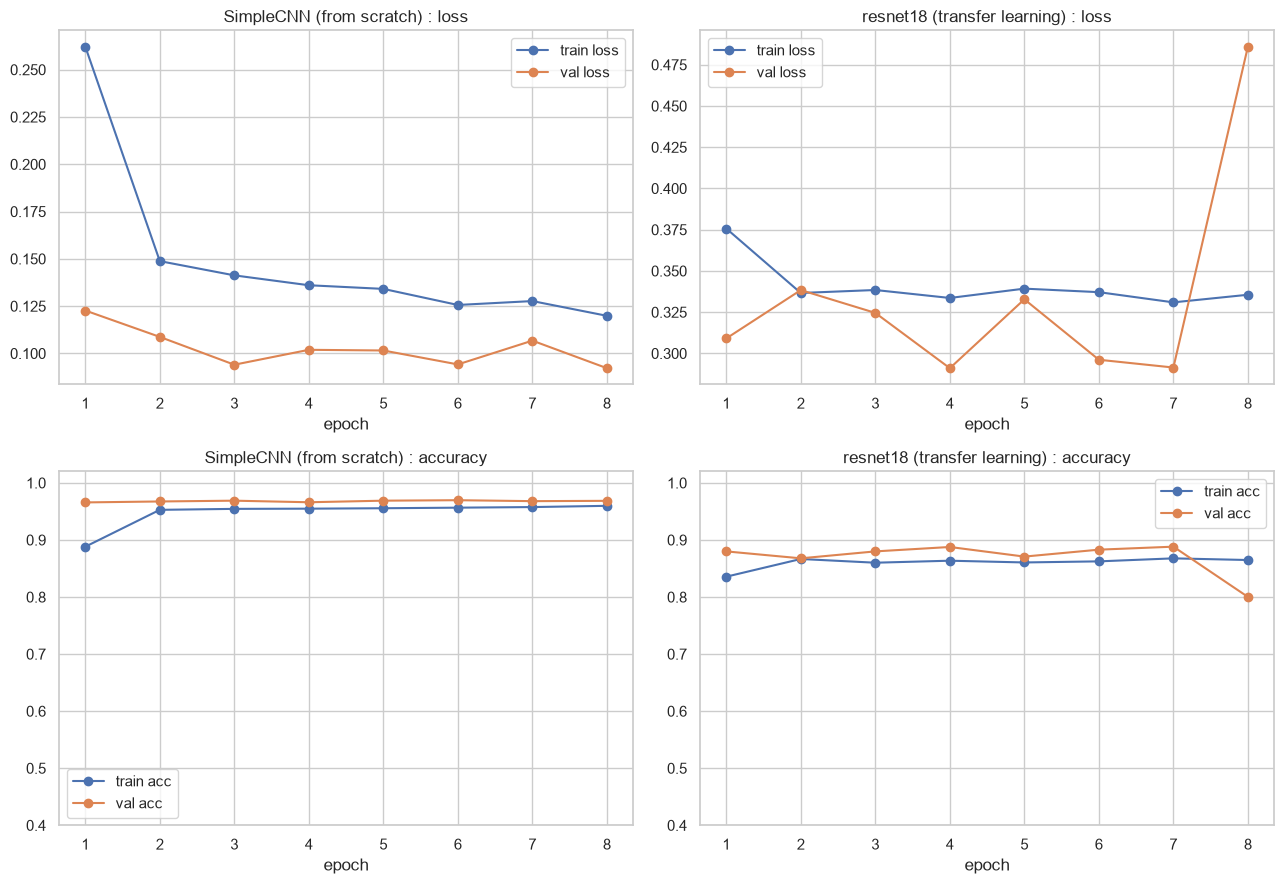

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, hist, title in zip(axes[0], [history_cnn, history_resnet], ["SimpleCNN (from scratch)", "resnet18 (transfer learning)"]):
    epochs_range = range(1, EPOCHS + 1)
    ax.plot(epochs_range, hist["train_loss"], marker="o", label="train loss")
    ax.plot(epochs_range, hist["val_loss"], marker="o", label="val loss")
    ax.set_title(f"{title} : loss")
    ax.set_xlabel("epoch")
    ax.legend()

for ax, hist, title in zip(axes[1], [history_cnn, history_resnet], ["SimpleCNN (from scratch)", "resnet18 (transfer learning)"]):
    epochs_range = range(1, EPOCHS + 1)
    ax.plot(epochs_range, hist["train_acc"], marker="o", label="train acc")
    ax.plot(epochs_range, hist["val_acc"], marker="o", label="val acc")
    ax.set_title(f"{title} : accuracy")
    ax.set_xlabel("epoch")
    ax.set_ylim(0.4, 1.02)
    ax.legend()

plt.tight_layout()
plt.show()

Les courbes confirment visuellement la convergence stable du SimpleCNN et la plus forte variabilité de la ResNet18. Le tableau suivant rassemble les métriques finales, le meilleur score atteint, le nombre de paramètres entraînables et le temps de calcul pour décider sur une base commune.


In [10]:
comparison = pd.DataFrame({
    "model": ["SimpleCNN (from scratch)", "resnet18 (transfer learning)"],
    "trainable_params": [
        sum(p.numel() for p in simple_cnn.parameters() if p.requires_grad),
        sum(p.numel() for p in resnet_transfer.parameters() if p.requires_grad),
    ],
    "final_val_loss": [history_cnn["val_loss"][-1], history_resnet["val_loss"][-1]],
    "final_val_accuracy": [history_cnn["val_acc"][-1], history_resnet["val_acc"][-1]],
    "final_val_f1_parasitized": [history_cnn["val_f1"][-1], history_resnet["val_f1"][-1]],
    "best_val_accuracy": [max(history_cnn["val_acc"]), max(history_resnet["val_acc"])],
    "training_time_sec": [round(time_cnn, 1), round(time_resnet, 1)],
})
display(comparison)

,model,trainable_params,final_val_loss,final_val_accuracy,final_val_f1_parasitized,best_val_accuracy,training_time_sec
0,SimpleCNN (from scratch),548258,0.092198,0.968534,0.963368,0.969638,324.9
1,resnet18 (transfer learning),1026,0.486035,0.800166,0.807651,0.888214,418.8


> **Décision de modèle.** Le SimpleCNN est retenu : meilleure accuracy de validation (**0,9696** contre **0,8882**), meilleur F1 final sur `Parasitized` (**0,9634** contre **0,8077**) et entraînement plus court (**324,9 s** contre **418,8 s**). Sur ce benchmark, une architecture compacte apprise sur le domaine surpasse le transfert d'une ResNet18 au backbone entièrement gelé.


### Lecture de la comparaison

La cellule ci-dessus affiche des chiffres réels, tout juste calculés, l'interprétation découle directement de ce tableau plutôt que d'une hypothèse posée à l'avance sur l'approche qui l'emporterait sur ce dataset.

## 8. Sauvegarde du meilleur modèle

In [11]:
best_idx = comparison["best_val_accuracy"].idxmax()
best_model_name = comparison.loc[best_idx, "model"]

if "resnet18" in best_model_name:
    best_model = resnet_transfer
    architecture = "resnet18_transfer"
else:
    best_model = simple_cnn
    architecture = "simple_cnn"

checkpoint = {
    "architecture": architecture,
    "state_dict": best_model.state_dict(),
    "img_size": IMG_SIZE,
    "imagenet_mean": IMAGENET_MEAN,
    "imagenet_std": IMAGENET_STD,
    "label_to_idx": LABEL_TO_IDX,
    "val_accuracy": comparison.loc[best_idx, "final_val_accuracy"],
    "val_f1_parasitized": comparison.loc[best_idx, "final_val_f1_parasitized"],
}
torch.save(checkpoint, MODELS_DIR / "best_model.pt")

display(
    Markdown(
        f"**Meilleur modèle retenu :** `{best_model_name}`  \n"
        f"Sauvegardé dans `models/best_model.pt` avec une accuracy de validation finale de `{checkpoint['val_accuracy']:.4f}` "
        f"et un F1 de validation (Parasitized) de `{checkpoint['val_f1_parasitized']:.4f}`."
    )
)

**Meilleur modèle retenu :** `SimpleCNN (from scratch)`  
Sauvegardé dans `models/best_model.pt` avec une accuracy de validation finale de `0.9685` et un F1 de validation (Parasitized) de `0.9634`.

> **Résultat.** Le checkpoint `models/best_model.pt` contient le SimpleCNN et ses métadonnées de prétraitement. Sa sauvegarde découple l'évaluation finale du code d'entraînement et évite toute nouvelle sélection sur le jeu de test.


## Résumé

* Les deux modèles sont entraînés sur toutes les images du split d'entraînement, puis évalués sur le split de validation complet.
* Le tableau de comparaison et les courbes ci-dessus sont lus directement à partir de cette exécution, pas supposés. Voir la Section 7 pour l'accuracy, le F1 et le temps d'entraînement réels de chaque modèle.
* Le meilleur modèle selon l'accuracy de validation est sauvegardé dans `models/best_model.pt` (ignoré par git) avec assez de métadonnées (nom de l'architecture, taille d'image, statistiques de normalisation, mapping des labels) pour que le Notebook 04 puisse le recharger sans avoir à relire ce notebook.
* Le Notebook 04 évalue ce modèle sauvegardé sur le jeu de test mis de côté, qu'aucun des deux modèles n'a vu pendant l'entraînement ou la sélection de modèle ici.

## Décisions pour le Notebook 04

1. Évaluer une seule fois le checkpoint retenu sur les 4 020 images du test isolé.
2. Rapporter sensibilité, spécificité, VPP, VPN, ROC-AUC et matrice de confusion, pas uniquement l'accuracy.
3. Tester l'effet de prévalences plus réalistes sur les valeurs prédictives.
4. Examiner des cartes de saillance avant de formuler une conclusion sur la plausibilité visuelle du modèle.
